# Experiment 1: Comparing Actor Size on a Fixed Circuit

## Study Design

### Research Question

> **RQ1**: How does actor-network capacity affect training an agent to race a car on one fixed circuit?

**RQ1** is answered by observing, in practice, four measures of training efficiency and efficacy:
* **Final driving performance**. How fast does the agent complete the lap (if they manage to complete it)?
* **Interaction efficiency**. How many interactions with the environment does the agent have to perform before reaching the task threshold?
* **Convergence reliability**. How do different runs under the same settings vary in the results?
* **Computational cost**. How long does the training take for the agent to reach the task threshold?

The actor-size comparison is repeated for REINFORCE, A2C+GAE and PPO. 
The algorithm comparison is secondary: it describes the practical effect of adding a critic, GAE and bounded sample reuse.

### Design Matrix

$3$ algorithms and $4$ network sizes are compared, for a total of $3 \times 4=12$ training configurations. Each configuration has five paired root identities, `0` through `4`, for $60$ runs in the combined study.

The original small, medium and large cells account for 45 completed runs. The tiny `(8, 8)` actor adds 15 runs under the same fixed conditions and roots. The report treats the 60 runs as one Experiment 1 while retaining the run records that identify the historical and newly added cells.

| Algorithm \ Size | `(8, 8)` tiny | `(32, 32)` small | `(64, 64)` medium | `(256, 256)` large |
|---|---:|---:|---:|---:|
| REINFORCE | 5 roots | 5 roots | 5 roots | 5 roots |
| A2C+GAE | 5 roots | 5 roots | 5 roots | 5 roots |
| PPO | 5 roots | 5 roots | 5 roots | 5 roots |

### Fixed Conditions

Every run uses:

* The saved `tracks/experiment_1.json` circuit, with its canonical start for the evaluation runs;
* Frenet observations $(d_t,\phi_{e,t},v_t,\delta_t,\bar\kappa_t)$;
* A bounded Gaussian policy, trained with Adam optimizer;
* In the cases of A2C and PPO, one fixed `(64, 64)` critic network;
* The learning rate selected before the experiment for its algorithm;
* A budget of $2\,000\,000$ training interactions;
* A deterministic evaluation over the `experiment_1` circuit every $50\,000$ training interactions;
* A checkpoint is saved every $250\,000$ interactions and at the end.

### Learning Rates:

Learning Rates for the 3 algorithms are set using a grid search on multiple reasonable values.
The grid search used the medium size for all actors and ran for a limited number of training interactions.

The final **learning rates** are:

| Algorithm | Actor learning rate | Critic learning rate | 
|---|---:|---:|
| REINFORCE | `1e-3` | — |
| A2C+GAE | `1e-3` | `3e-3` |
| PPO | `3e-4` | `1e-2` |

## Experimental Results

**Status:** 60 completed training runs; 2 million training interactions per run; a total of **396.2 minutes** (6.6h) of run time.


The following demo loads the final A2C Medium policy from root 0. A2C Medium is best overall by mean final return (by very little compared with A2C Small).

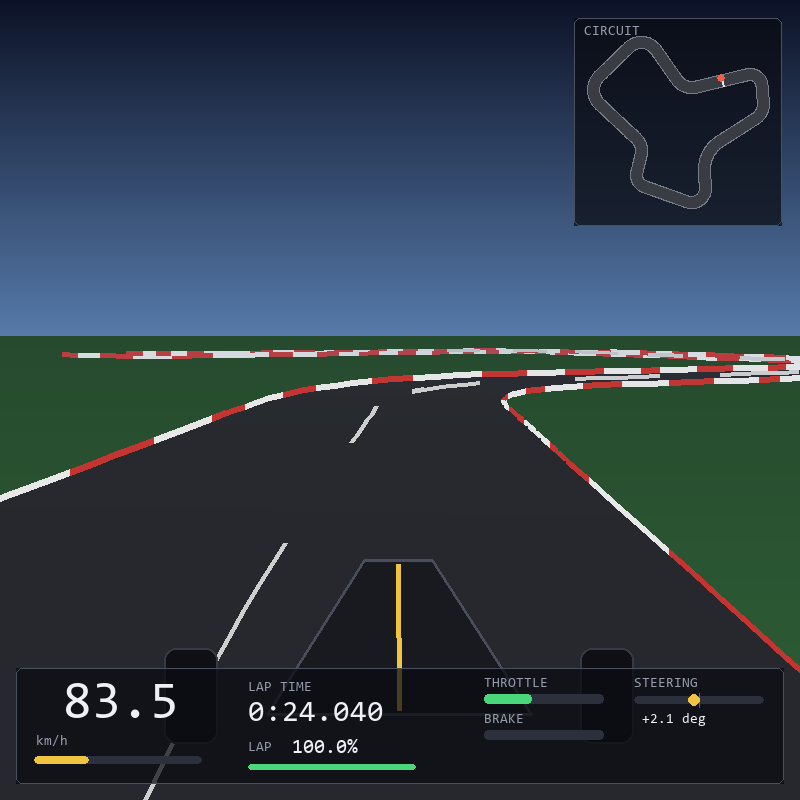

Completed: True | Time: 24.04 s


In [1]:
from pathlib import Path
from time import sleep

from IPython.display import display
from PIL import Image

from configs import EnvironmentConfig, StartStateConfig
from envs import RacingEnv, TrackWithGeometry
from experiments.presentation_demo import SavedActor

seed = 0
run = Path("results/reported_experiments/experiment_1/a2c-medium-frenet-seed-0")
policy = SavedActor.from_run(run, seed=seed)

config = EnvironmentConfig(start=StartStateConfig(randomized=False))
env = RacingEnv(
    TrackWithGeometry.load("tracks/experiment_1.json"),
    config=config,
    render_mode="rgb_array",
)
observation, _ = env.reset(seed=seed)
viewer = display(Image.fromarray(env.render()), display_id=True)

try:
    for step in range(config.simulation.max_episode_steps):
        action = policy.action(observation)
        observation, reward, terminated, truncated, info = env.step(action)
        if step % 2 == 0 or terminated or truncated:
            viewer.update(Image.fromarray(env.render()))
            sleep(2 * config.simulation.agent_timestep)
        if terminated or truncated:
            break
finally:
    env.close()

print(f"Completed: {info['lap_completed']} | Time: {info['elapsed_time']:.2f} s")

### RQ1.1 Final Driving Performance

The table reports the final performance of each Algorithm-Size combination after the full budget of 2M interactions:

| Algorithm | Actor | Completed laps | Return mean ± SD | Return 95% interval | Progress | Lap time (s), completed only |
|---|---|---:|---:|---|---:|---:|
| REINFORCE | Tiny | 2/5 | 116.30 ± 89.81 | [48.21, 184.39] | 0.867 | 27.94 |
| **REINFORCE** | **Small** | **5/5** | **205.49 ± 9.05** | **[198.78, 213.02]** | **1.000** | **29.88** |
| REINFORCE | Medium | 5/5 | 205.31 ± 10.34 | [197.60, 213.73] | 1.000 | 29.92 |
| REINFORCE | Large | 4/5 | 159.06 ± 92.65 | [76.63, 207.43] | 0.803 | 31.08 |
| A2C | Tiny | 3/5 | 148.88 ± 102.94 | [73.38, 224.38] | 0.823 | 25.76 |
| A2C | Small | 5/5 | 227.84 ± 2.92 | [225.53, 229.97] | 1.000 | 24.91 |
| **A2C** | **Medium** | **5/5** | **227.98 ± 2.40** | **[226.37, 230.00]** | **1.000** | **24.90** |
| A2C | Large | 5/5 | 201.67 ± 10.02 | [194.06, 209.79] | 1.000 | 30.74 |
| PPO | Tiny | 5/5 | 215.70 ± 4.10 | [212.33, 218.44] | 1.000 | 27.62 |
| PPO | Small | 4/5 | 187.15 ± 69.00 | [124.72, 223.33] | 0.984 | 27.16 |
| PPO | Medium | 5/5 | 220.61 ± 9.42 | [213.69, 228.58] | 1.000 | 26.52 |
| **PPO** | **Large** | **5/5** | **220.97 ± 5.51** | **[216.77, 225.17]** | **1.000** | **26.45** |

There is no consistent monotonic benefit from increasing actor size across the three algorithms.

There are instead some interesting patterns that emerge at a specific-algorithm level:

* **REINFORCE** benefits clearly in these runs from moving beyond a **tiny** actor, with which three roots out of five fail to complete a lap. It also benefits from staying below the **large** actor size.

* **A2C** has the best mean final driving performance across the tested algorithms, both with a **small** and **medium** sized actor. Similarly to REINFORCE, **tiny** appears to fail and **large** is not as quick as the smaller sizes.

* **PPO** learns even with the **tiny** actor. It is mostly consistent across all sizes, with a slightly better mean return at **large**.

<img src="docs/figures/presentation/final_returns.png" alt="Final return distributions for all twelve algorithm-size configurations" width="1200" style="max-width: 100%;">

### RQ1.2 Interaction Efficiency

To determine whether actor size affected learning speed, we compare returns over training interactions and first task-threshold attainment. The threshold requires three consecutive deterministic evaluations completing a lap within $34s$; first attainment is the first checkpoint in that streak, and confirmation is $100\,000$ interactions later. Attainment does not guarantee subsequent stability.

* **REINFORCE** shows that the **tiny** actor takes more interactions to reach the threshold: the three attaining roots average $933\,000$. **Small** and **medium** attain in all five roots, averaging $480\,000$ and $440\,000$ interactions. **Large** averages $313\,000$ among its four attaining roots, but one root never attains.

<div style="display: flex; max-width: 1200px; width: 100%;">
  <img src="docs/figures/presentation/reinforce_training_returns.png" alt="REINFORCE exploratory training returns by actor size" style="width: 50%; min-width: 0; object-fit: contain;">
  <img src="docs/figures/presentation/reinforce_evaluation_returns.png" alt="REINFORCE deterministic evaluation returns by actor size" style="width: 50%; min-width: 0; object-fit: contain;">
</div>

* **A2C** shows a similar disadvantage for **tiny**, whose three attaining roots average $1.72$ million interactions. Its best final sizes, **small** and **medium**, attain in all five roots but take longer than REINFORCE: $800\,000$ and $760\,000$ interactions on average.

<div style="display: flex; max-width: 1200px; width: 100%;">
  <img src="docs/figures/presentation/a2c_training_returns.png" alt="A2C exploratory training returns by actor size" style="width: 50%; min-width: 0; object-fit: contain;">
  <img src="docs/figures/presentation/a2c_evaluation_returns.png" alt="A2C deterministic evaluation returns by actor size" style="width: 50%; min-width: 0; object-fit: contain;">
</div>

* **PPO** reaches the threshold with every size and every root. All first attainments occur by $200\,000$ interactions; size-level means range from $80\,000$ to $130\,000$.

<div style="display: flex; max-width: 1200px; width: 100%;">
  <img src="docs/figures/presentation/ppo_training_returns.png" alt="PPO exploratory training returns by actor size" style="width: 50%; min-width: 0; object-fit: contain;">
  <img src="docs/figures/presentation/ppo_evaluation_returns.png" alt="PPO deterministic evaluation returns by actor size" style="width: 50%; min-width: 0; object-fit: contain;">
</div>

The main factor conditioning these results is the algorithm itself. PPO's repeated mini-batch updates help explain its interaction efficiency. A2C being slower than REINFORCE is plausible here: it makes one update per rollout and relies on learned bootstrap values, while REINFORCE uses complete returns. Critic error, the GAE bias?variance tradeoff and the selected learning rates may contribute; this experiment does not isolate their effects.


### RQ1.3 Convergence Reliability

Convergence reliability can mostly be measured **across roots**.

In general, all cases where the algorithm-size pair managed to converge consistently ($5/5$ completed laps at the end) all had a relatively small standard deviation for their return values. 

This describes similar final-return consistency among the successful configurations, but does not establish equal convergence reliability. PPO Small, for example, reaches the threshold in all five roots but finishes successfully in only four. A **much larger number of roots** would be needed for stronger reliability comparisons.

### RQ1.4 Computational Cost

The chart shows how the mean end-to-end duration is divided across four phases. Other overhead includes persistence and the remaining run overhead.

<img src="docs/figures/presentation/runtime_phases.png" alt="Run-time shares for collection, optimization, evaluation and other overhead" width="800" style="max-width: 100%;">

The table reports per-run means across five roots, for the full $2$ million-interaction budget:

| Algorithm / actor | End-to-end (min) | Collection interactions/s |
|---|---:|---:|
| REINFORCE / Tiny | 5.31 | 6,964 |
| REINFORCE / Small | 5.57 | 6,658 |
| REINFORCE / Medium | 5.39 | 6,899 |
| REINFORCE / Large | 6.75 | 6,012 |
| A2C / Tiny | 5.63 | 6,680 |
| A2C / Small | 5.70 | 6,626 |
| A2C / Medium | 5.77 | 6,581 |
| A2C / Large | 6.10 | 6,566 |
| PPO / Tiny | 7.99 | 6,805 |
| PPO / Small | 7.82 | 7,102 |
| PPO / Medium | 8.23 | 6,680 |
| PPO / Large | 8.98 | 6,648 |

PPO is slowest over the full budget, as expected from its repeated optimization epochs. A2C is slightly slower than REINFORCE at tiny, small and medium sizes because it also trains a critic; at large, A2C is faster overall. Despite its greater full-budget cost, PPO reaches the task threshold fastest in measured training time as well as interactions.


# Limitations and Future Work

Results should be interpreted with a critical eye over (at least) five aspects of the experiment:

* **Five roots per configuration** limit uncertainty estimates and reliability comparisons. The reported 95% intervals bootstrap the five root-level final returns.
* **One fixed circuit and Frenet observations** limit the findings to this specific task.
* **Algorithm-specific learning rates**, selected with the medium actor, may favour some sizes. A size-specific tuning study would separate capacity from optimization effects.
* **Simplified vehicle physics and partial observations** limit realism. 
* Actor-critic methods **bootstrap at time-limit truncations**, whereas REINFORCE stops its return there; this affects the algorithm comparison.
